#  «Аналитика клиентов и логов gamedev-стартапа»


**Описание данных:**

user_data:

- client – идентификатор пользователя  
- premium – есть ли у клиента премиум статус  
- age – возраст  

logs:

- client – идентификатор пользователя  
- success – результат ответа (операции): успех - 1, нет - 0  
- platform – платформа  
- time – время в формате Unix

### Шаг 1

Импортируем нужные библиотеки и соединяем данные из разных таблиц. Изучаем структуру данных.
Проверяем типы данных, смотрим есть ли дубликаты в данных и пустые значения в столбцах, которые критичны для анализа.


In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline



In [50]:
user_data = pd.read_csv("~/Gamedev project/user_data.csv")



In [144]:
user_data.head()

,client,premium,age
0,46346,False,58
1,4391,False,55
2,27372,False,64
3,11989,False,44
4,60664,False,49


In [51]:
user_data.shape

(2954, 3)

In [52]:
user_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2954 entries, 0 to 2953
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   client   2954 non-null   int64
 1   premium  2954 non-null   bool 
 2   age      2954 non-null   int64
dtypes: bool(1), int64(2)
memory usage: 49.2 KB


In [53]:
user_data.dtypes

client     int64
premium     bool
age        int64
dtype: object

In [54]:
user_data.isnull().sum()

client     0
premium    0
age        0
dtype: int64

In [55]:
user_data.duplicated().sum()

0

In [56]:
logs = pd.read_csv("~/Gamedev project/logs.csv")


In [145]:
logs.head()

,client,success,platform,time
0,40177,True,phone,2020-03-28 16:16:52
1,61468,True,phone,2020-03-28 20:00:58
2,35604,False,phone,2020-03-29 05:31:34
3,9961,True,phone,2020-03-28 12:56:29
4,10931,True,computer,2020-03-29 07:57:09


In [57]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   client    4500 non-null   int64 
 1   success   4500 non-null   bool  
 2   platform  4500 non-null   object
 3   time      4500 non-null   int64 
dtypes: bool(1), int64(2), object(1)
memory usage: 110.0+ KB


In [77]:
logs['time'] =pd.to_datetime(logs['time'], unit='s')

In [78]:
logs.shape

(4500, 4)

In [79]:
logs.duplicated().sum()

0

In [80]:
logs.isnull().sum()

client      0
success     0
platform    0
time        0
dtype: int64

## Шаг 2
Посчитаем основные метрики.
Среди полученных данных можно выделить для анализа:
- Долю успешных операций;
- Количество активных пользователей;
- Среднее количество операций на 1 пользователя (поймем насколько аудитория активна);
- Долю премиум пользователей;
- Доля пользователей по плафтформам;
- Среднее время между операциями у пользователей (сможем выделить аномальные случаи);
- Соотношение успех/неудача.

In [81]:
#Доля успешных операций
logs.success.mean()*100

73.08888888888889

In [82]:
#Количество активных пользователей
logs['client'].nunique()

4011

In [148]:
#Среднее количество операций на 1 пользователя
logs.groupby('client').size().mean()

1.1219147344801794

In [84]:
#Доля премиум пользователей
#Для расчета сначала соединим ищеющиеся таблицы
merged_game_data = logs.merge(user_data, on='client', how='left')
#а затем посчитаем долю
merged_game_data[merged_game_data['premium'] == True]['success'].mean()*100

72.14285714285714

In [85]:
merged_game_data.head()

,client,success,platform,time,premium,age
0,40177,True,phone,2020-03-28 16:16:52,NaN,NaN
1,61468,True,phone,2020-03-28 20:00:58,False,25.0
2,35604,False,phone,2020-03-29 05:31:34,True,65.0
3,9961,True,phone,2020-03-28 12:56:29,NaN,NaN
4,10931,True,computer,2020-03-29 07:57:09,False,28.0


In [162]:
#Доля пользователей по платформам
users_plaform = merged_game_data.groupby('platform')['client'].count()
users_plaform

platform
computer    1505
phone       2753
tablet       242
Name: client, dtype: int64

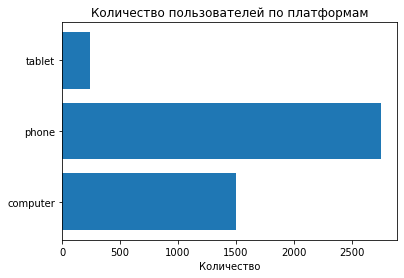

In [164]:
plt.barh(users_plaform.index, users_plaform.values)
plt.title('Количество пользователей по платформам')
plt.xlabel('Количество')
plt.show()

In [175]:
#Среднее время между операциями
logs_sorted  = logs.sort_values(['client', 'time'])
logs_sorted['time_diff'] = logs_sorted.groupby('client')['time'].diff()
logs_sorted['time_diff'] = logs_sorted['time_diff'].dt.total_seconds()/60
mean_minutes = logs_sorted['time_diff'].mean()
median_minutes = logs_sorted['time_diff'].median()
print(f"Среднее значение: {round(mean_minutes, 2)} минут")
print(f"Медианное значение: {round(median_minutes, 2)} минут")

Среднее значение: 100.17 минут
Медианное значение: 28.08 минут


Text(0, 0.5, 'Частота')

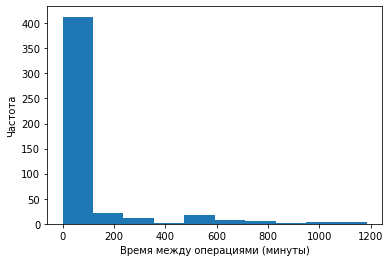

In [185]:
#Построим график для наглядности анализа рапсределения частоты 
plt.hist(logs_sorted['time_diff'])
plt.xlabel('Время между операциями (минуты)')
plt.ylabel('Частота')


In [113]:
#Соотношение успех/неудача
logs_sorted['success'].value_counts(normalize=True) * 100

True     73.088889
False    26.911111
Name: success, dtype: float64

In [178]:
#Количество удачных операций по платформам

logs.loc[logs.success == True].platform.value_counts()

phone       2019
computer    1090
tablet       180
Name: platform, dtype: int64

In [177]:
#Количество неудачных операций по платформам

logs.loc[logs.success == False].platform.value_counts()

phone       734
computer    415
tablet       62
Name: platform, dtype: int64

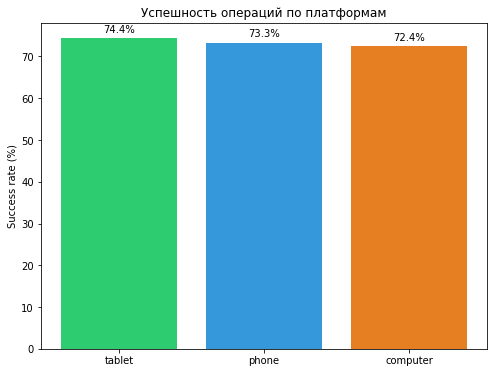

In [184]:
# Построим график для анализа рейтинга успещности операций по платформам

platform_success = logs.groupby('platform')['success'].mean() * 100
platform_success = platform_success.sort_values(ascending=False)

plt.figure(figsize=(8,6))
plt.bar(platform_success.index, platform_success.values, color=['#2ecc71', '#3498db', '#e67e22'])
plt.ylabel('Success rate (%)')
plt.title('Успешность операций по платформам')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%', ha='center', va='bottom')
plt.show()

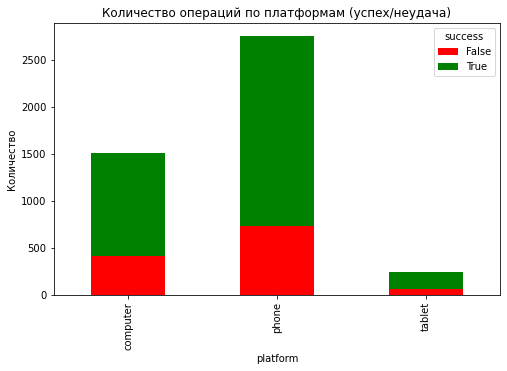

In [187]:
#построим график по количеству успешных/неуспешных операций по платформам

counts = logs.groupby(['platform', 'success']).size().unstack(fill_value=0)
counts.plot(kind='bar', stacked=True, figsize=(8,5), color=['red', 'green'])
plt.title('Количество операций по платформам (успех/неудача)')
plt.ylabel('Количество')
plt.show()

In [186]:
#проведем анализ сегмента премиум пользователей
premium_users = merged_game_data[merged_game_data['premium'] == True]
premium_users.head()

,client,success,platform,time,premium,age
2,35604,False,phone,2020-03-29 05:31:34,True,65.0
10,11983,True,phone,2020-03-29 05:25:11,True,68.0
17,99308,True,computer,2020-03-28 15:30:09,True,38.0
27,49625,False,phone,2020-03-29 02:09:49,True,65.0
33,53978,True,computer,2020-03-28 15:17:17,True,46.0


In [141]:
#Успешность операций по платформам у премиум пользователей
premium_users.groupby('platform')['success'].mean() * 100

platform
computer    72.00000
phone       71.95122
tablet      75.00000
Name: success, dtype: float64

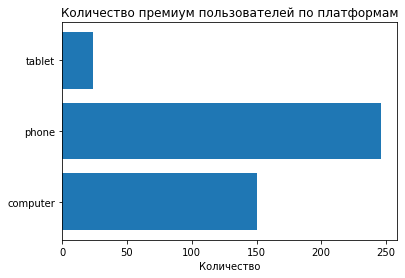

In [188]:
#построим график по количеству премиум пользователей по плафтормам
plt.barh(premium_users_plaform.index, premium_users_plaform.values)
plt.title('Количество премиум пользователей по платформам')
plt.xlabel('Количество')
plt.show()

## **Выводы по полученным расчетам:**  

- Общий success rate — 73%, что является хорошим показателем.  
- Премиум-пользователи не показывают статистически значимого отличия в успехе от обычных (72% против 73%, p>0.05).   Функционал премиума, вероятно, не связан с технической стабильностью, возможно стоит обратить внимание разработки на дополнительную поддержку и помощь премиум клиентам.  
- Телефон является основной платформой для премиум-клиентов. Это может быть связано с тем, что мобильная версия продукта более популярна. Планшет привлекает мало премиум-пользователей – возможно, нишевое устройство или продукт не оптимизирован под планшеты.
- Доля успеха визуально одинакова на всех платформах (зелёная часть преобладает). На планшете доля успеха чуть выше, но из-за малого объёма это может быть случайностью.
- В данных есть «потерянные» клиенты — 30% активных пользователей не имеют записи в user_data. Возможно есть проблемы в качестве данных или особенности пользования приложением.  
- Среднее время между операциями ~100 минут, но медиана ~28 минут, что свидетельствует о выбросах в данных.

## Шаг 3
Обратим внимание на данные о возрасте и посмотрим на различие в возрасте у премиум и обычных пользователей.

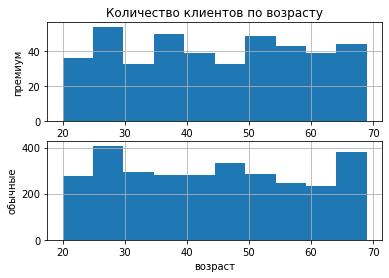

In [189]:
plt.subplot(2, 1, 1)
# построение графика
plt.hist(merged_game_data.query('premium == True').age)
# заголовок
plt.title("Количество клиентов по возрасту")
# ось ординат
plt.ylabel("премиум")
plt.grid(True)

plt.subplot(2, 1, 2)
# построение графика
plt.hist(merged_game_data.query('premium == False').age)
# ось абсцисс
plt.xlabel("возраст")
# ось ординат
plt.ylabel("обычные")
plt.grid(True)

## **Выводы по полученным расчетам:**  

- премиум-клиентов возраста примерно 35-39 лет меньше, чем обычных клиентов этого же возраста. 
- среди премиум-клиентов больше тех, кому примерно 25-30 лет, чем тех, кому примерно 20-25 лет.
- у нас чуть больше 40 премиум-клиентов возраста ориентировочно 65-69 лет.

## Шаг 3
Проведем сегментацию по возрастным группам.

In [216]:
#Определяем границы групп
bins = [0, 25, 35, 50, 100]
labels = ['18-24', '25-34', '35-49', '50+']

#Добавляем колонку age_group в объединённые данные (только где age не NaN)
merged_game_data['age_group'] = pd.cut(merged_game_data['age'], bins=bins, labels=labels, right=False)

In [219]:
#1 Средний success rate по возрастным группам
age_success = merged_game_data.groupby('age_group')['success'].mean() * 100
print("Успех по возрастам:\n", age_success)

#2 Доля премиум в каждой возрастной группе
premium_share_by_age = merged_game_data.groupby('age_group')['premium'].mean() * 100
print("Доля премиум:\n", premium_share_by_age)


Успех по возрастам:
 age_group
18-24    77.884615
25-34    74.683544
35-49    72.074730
50+      74.318182
Name: success, dtype: float64
Доля премиум:
 age_group
18-24    11.538462
25-34    11.012658
35-49    11.996067
50+      13.257576
Name: premium, dtype: float64


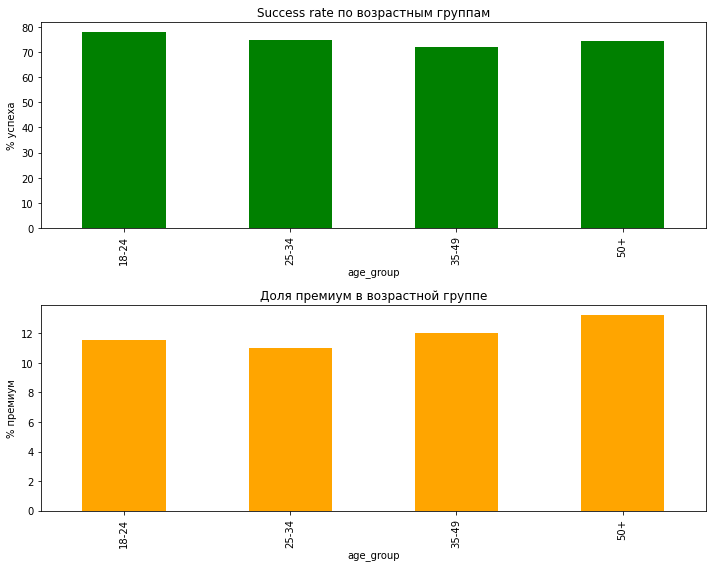

In [220]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8)) 

age_success.plot(kind='bar', ax=axes[0], color='green')
axes[0].set_title('Success rate по возрастным группам')
axes[0].set_ylabel('% успеха')

premium_share_by_age.plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Доля премиум в возрастной группе')
axes[1].set_ylabel('% премиум')

plt.tight_layout()
plt.show()

## **Выводы по полученным расчетам:**  

- премиум-клиентов возраста примерно 35-39 лет меньше, чем обычных клиентов этого же возраста. 
- среди премиум-клиентов больше тех, кому примерно 25-30 лет, чем тех, кому примерно 20-25 лет.
- у нас чуть больше 40 премиум-клиентов возраста ориентировочно 65-69 лет.


1. Успешность операций (Succes rate)
В сегменте 18–24 года: 77.9% - самый высокий показатель.

В сегменте 35–49 лет: 72.1% — самый низкий показатель. Это проблемная группа.
Причина может быть в сложности функций или в том, что они чаще используют старые устройства / операционные системы, на которых продукт работает хуже.

Вывод: Стоит обратить внимание на онбординг и подсказки для более возрастной группы, возможно есть сложности для этой группы.

2. Доля премиум-пользователей по возрасту
50+ лет: 13.3% — самая высокий показатель. Более платежеспособная аудитория

35–49 лет: 12.0% - так же на уровне.

18–24 года: 11.5%

25–34 года: 11.0% — самая низкая доля премиум.

Вывод: Молодёжь меньше платит, хотя достигает лучших результатов. Возможно, премиум-функции не нацелены на их потребности, либо у них меньше финансовой возможности. Продукту стоило бы предлагать дешёвые подписки или внутриигровые бонусы для удержания молодых, но успешных пользователей.

3. Аномалии, которые стоит проверить дополнительно

Низкая активность (операций на пользователя ~1.2) — из предыдущих расчётов видно, что среднее число операций на пользователя около 1.2. Это очень мало для gamedev-сервиса.
Что проверить:

Распределение числа операций на клиента: сколько пользователей сделали только 1 операцию? Если таких большинство (например, >70%), то продукт имеет проблему с удержанием (retention).

Возможно, логи собираются только для определённого типа событий (например, только успешных операций?), но у вас есть и неудачи. Тем не менее, стоит убедиться, что в логах действительно все действия пользователя.

In [230]:
#Исходя из полученных данных стоит посмотреть как много пользователей совершили только 1 операцию
ops_per_user = logs.groupby('client').size()

users_one_op = (ops_per_user == 1).sum()
total_users = len(ops_per_user)

share_one_op = users_one_op / total_users * 100

print(f"Всего уникальных пользователей: {total_users}")
print(f"Пользователей с 1 операцией: {users_with_one_op}")
print(f"Доля пользователей с 1 операцией: {share_one_op:.1f}%")

Всего уникальных пользователей: 4011
Пользователей с 1 операцией: 3915
Доля пользователей с 1 операцией: 97.6%


## **Выводы по полученным расчетам:**  

- 97.6% пользователей совершили только одну операцию и больше не возвращались.  
- Очевидно есть проблемы с удержанием пользователя.  
- Рекомендации - обратить внимание на онбординг, технические ошибки в продукте, сложность интерфейса.  